# 第8章 CartPole の続き（方策勾配法）：行動を選ぶ確率を直接学ぶ

[第7章](../ch07_cartpole_dqn/ch07_cartpole_dqn.ipynb)では、CartPole の行動ごとの価値（Q 値）をニューラルネットワークで見積もり、Q 値が大きいほうの行動を選ぶ DQN で解きました。この章では、同じ CartPole を、**方策勾配法** で解きます。方策勾配法では、Q 値を経由せず、「この観測なら、左へ押す確率は何%、右へ押す確率は何%」という **方策そのもの** をニューラルネットワークで表し、その確率を直接学習します。

まず、方策勾配法の系統の **A2C** を、Stable-Baselines3（SB3）で動かして楽しみます。次に、PyTorch で書いた短い **REINFORCE**（もっとも基本的な方策勾配法）のサンプルを読み、収益の標準化という工夫を外したときと比べます。最後に、第7章の DQN と結果を並べます。

- **前提**: [第7章 CartPole（DQN）](../ch07_cartpole_dqn/ch07_cartpole_dqn.ipynb)を終えていること
- **所要の目安**: 実行は CPU で 10 分ほど（著者の環境で、Notebook 全体を上から実行して約 6 分）
- **使う装置**: CPU で十分です（この章では GPU を使いません）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、Stable-Baselines3 2.9.0、PyTorch 2.14.1）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。学習にかかる時間は、パソコンによって変わります。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. 方策勾配法が、Q 値ではなく、行動を選ぶ確率を学習する手法であることを説明できる
2. SB3 の A2C を、RL Zoo の調整済みのハイパーパラメータで学習させ、成績・棒を立てる様子・学習中の評価を見られる
3. REINFORCE のサンプルで、行動を確率で選ぶ部分、収益を計算する部分、損失を作る部分がどの行に当たるかを説明できる
4. 収益の標準化を外したときに何が変わるかと、DQN との結果の違いを、測った値で説明できる

完了条件は、この Notebook を上から最後まで実行して、5節の REINFORCE のサンプルが残した「一番よい時点のネットワーク」が、100 回の評価で報酬の合計の平均 475 以上になることです（第7章と同じく、Gymnasium が CartPole-v1 を「解けた」とみなす目安の 475 を使います）。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | 動かして楽しむ：SB3 の A2C | 成績、棒を立てる様子 |
| 4節 | 読む(1)：方策ネットワーク | ネットワークの形と、出てくる確率と価値 |
| 5節 | 読む(2)：PyTorch の REINFORCE のサンプル | 確率で行動を選ぶ、収益、損失 |
| 6節 | 比べる：収益の標準化を外す | 2通りの設定の学習曲線と成績 |
| 7節 | 比べる：DQN と | 学習中の評価、使ったステップ数 |
| 8節 | 遊んでみる | 試してみる設定 |

方策勾配法と A2C は、概要資料の[強化学習の手法の地図](../../overview/rl.md)で、「ニューラルネットワークで近似する」領域の、方策オンの流れ（方策勾配法 → A2C → PPO）にある手法です。第1章で使った PPO も、この流れの先にあります。ニューラルネットワークの計算には PyTorch を使います（概要資料の [PyTorch](../../overview/pytorch.md)）。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う関数を用意します。

In [1]:
import copy
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from torch import nn

torch.set_num_threads(1)  # 計算に使うスレッドを1つにする（著者が seed を変えて測ったときの条件とそろえるため）

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


# 方策 policy（観測 → 行動の番号を返す関数）で episodes 回遊ばせ、報酬の合計の平均と標準偏差を返す
def evaluate(policy, episodes=100, seed=100):
    env = gym.make("CartPole-v1")
    totals = np.zeros(episodes)
    for i in range(episodes):
        observation, info = env.reset(seed=seed if i == 0 else None)
        while True:
            observation, reward, terminated, truncated, info = env.step(policy(observation))
            totals[i] += reward
            if terminated or truncated:
                break
    return totals.mean(), totals.std()


# 方策 policy で1エピソード遊ばせ、every ステップごとの (ステップ数, 絵) の一覧を返す（絵は Gymnasium の描画）
def record_episode(policy, seed, every=5):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    observation, info = env.reset(seed=seed)
    shots = [(0, env.render())]
    steps = 0
    while True:
        observation, reward, terminated, truncated, info = env.step(policy(observation))
        steps += 1
        if steps % every == 0 or terminated or truncated:
            shots.append((steps, env.render()))
        if terminated or truncated:
            return shots

関数の説明:

- `evaluate` と `record_episode` は、第7章と同じ関数です。`evaluate` は、方策（観測を受け取って行動の番号を返す関数）で 100 回遊ばせ、報酬の合計の平均と標準偏差を返します。最初の `reset` にだけ `seed=100` を渡すので、どの方策も、同じ始まり方の 100 回で比べられます。`record_episode` は、方策で1エピソード遊ばせ、5 ステップごとの絵（Gymnasium の CartPole の描画）を集めます

CartPole の観測と行動は、第7章の3-1節で見たとおりです（観測は台車の位置・速度、棒の角度・角速度の4つの小数、行動は 0 が左へ押す、1 が右へ押す）。でたらめな方策の報酬の合計の平均は 21.6 でした（第7章の3-2節）。

## 3. 動かして楽しむ：SB3 の A2C

### 3-1. 学習させる

SB3 の `A2C` で学習させます。SB3 には REINFORCE が入っていないので、同じ方策勾配法の系統で、SB3 に入っている A2C を使います（A2C と REINFORCE の関係は5-4節）。ハイパーパラメータは、第7章と同じく **RL Zoo** の、CartPole-v1 用の値を使います。RL Zoo の値は「8 つの環境を同時に進める（`n_envs=8`）」「500,000 ステップ学習する」「`ent_coef=0.0`」で、ほかの設定は SB3 の既定値です（出典は末尾）。

学習中の様子を見るために、`EvalCallback` で、ときどき 10 回遊ばせて評価し、その記録を `checkpoints` フォルダに保存します。著者の環境では 130 秒ほどかかりました。

In [2]:
# RL Zoo（v2.9.0）の A2C の CartPole-v1 用のハイパーパラメータ（出典は末尾）。書いていない設定は SB3 の既定値
train_env = make_vec_env("CartPole-v1", n_envs=8, seed=0)  # 8 つの環境を、順番に1歩ずつ進める
model = A2C("MlpPolicy", train_env, ent_coef=0.0, seed=0, device="cpu", tensorboard_log="logs")
# 2,500 回の呼び出しごと（8 つの環境なので 20,000 ステップごと）に 10 回遊ばせて評価し、記録を checkpoints/ に保存する
eval_callback = EvalCallback(make_vec_env("CartPole-v1", n_envs=1, seed=200), n_eval_episodes=10, eval_freq=2500,
                             log_path="checkpoints/a2c_cartpole", verbose=0)

start = time.perf_counter()
model.learn(total_timesteps=500_000, callback=eval_callback, tb_log_name="a2c_cartpole")
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print("学習中のエピソードの数（8 つの環境の合計）:", sum(len(e.get_episode_rewards()) for e in train_env.envs))
a2c_evals = np.mean(eval_callback.evaluations_results, axis=1)
print("20,000 ステップごとの評価（10 回の平均）:", np.round(a2c_evals, 1))

学習にかかった時間: 127 秒
学習中のエピソードの数（8 つの環境の合計）: 1522
20,000 ステップごとの評価（10 回の平均）: [183.5 150.5 183.8 111.8 500.  500.  500.  500.  500.  500.  500.  500.
 500.  500.  500.  500.  500.  500.  500.  500.  500.  500.  500.  500.
 500. ]


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 127 秒でした（パソコンによって変わります）。500,000 ステップの間に、8 つの環境で合わせて 1,522 回のエピソードがありました。20,000 ステップごとの評価（10 回の平均）は、20,000〜80,000 ステップでは 111.8〜183.8 で、100,000 ステップで 500.0 になり、そのあとは最後の 500,000 ステップまで、25 回の評価のうち残りの 21 回がすべて 500.0 です。

`EvalCallback` の `eval_freq` は、ステップ数ではなく、環境をまとめて1歩進める呼び出しの回数で数えます。8 つの環境を同時に進めるので、1回の呼び出しで 8 ステップ進み、2,500 回の呼び出しは 20,000 ステップです。

`seed=0`（学習）と `seed=200`（学習中の評価の環境）を固定しています。著者の環境では、この Notebook を2回実行して、学習と評価の結果（時間以外）が同じになりました（確かめたのは同じパソコンでの実行です）。`checkpoints` フォルダと `logs` フォルダは、学習のたびに作り直せるものなので、Git の管理から外しています。

### 3-2. 成績を測る

学習の最後の時点のモデルを、100 回評価します。

In [3]:
mean, std = evaluate(lambda observation: int(model.predict(observation, deterministic=True)[0]))
print(f"最後の時点のモデル: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

最後の時点のモデル: 報酬の合計の平均 500.0、標準偏差 0.0


**期待する結果**（上の出力の読み方）: 最後の時点（500,000 ステップ）のモデルは、報酬の合計の平均が 500.0、標準偏差が 0.0 で、100 回すべてで上限の 500 回まで棒を立て続けました。

著者が学習の seed を 0〜4 に変えて測ったところ、最後の時点のモデルは、どの seed でも 500.0 でした。第7章の DQN では、最後の時点のモデルが seed によって大きく違ったので、一番よい時点のモデルを残しました。この章の A2C では、最後の時点のモデルを使います。

`deterministic=True` は、確率が一番大きい行動を選ぶ指定です（4節）。

### 3-3. 棒を立てる様子を見る

最後の時点のモデルで1エピソード遊ばせ、5 ステップごとの絵を GIF に保存します。

続いた回数: 500


GIF の枚数: 101


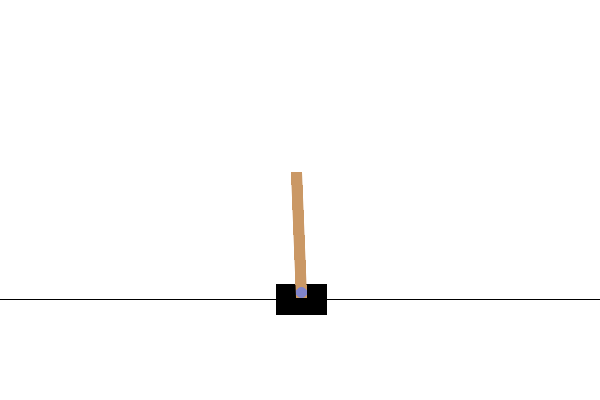

In [4]:
shots = record_episode(lambda observation: int(model.predict(observation, deterministic=True)[0]), seed=0)
print("続いた回数:", shots[-1][0])
imageio.v3.imwrite(FIGURES / "ch08_a2c.gif", [frame for _, frame in shots], duration=100, loop=0)
print("GIF の枚数:", len(shots))
Image(filename=FIGURES / "ch08_a2c.gif")

**期待する結果**（上の出力の読み方）: 最後の時点のモデルは、`seed=0` で始めたこのエピソードで、上限の 500 回まで棒を立て続けました。GIF には、最初の絵と 5 ステップごとの絵 100 枚の、合わせて 101 枚を書き込みます。1 枚を 100 ミリ秒で表示するので、第7章と同じく、ほぼ実際の速さです。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、3-3節の GIF です。台車は真ん中からゆっくり左へ動いていき、最後は台車1台分ほど左にいます。その間、棒はほぼまっすぐに立ち続けます。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じエピソードのコマ送りの図を作ります。

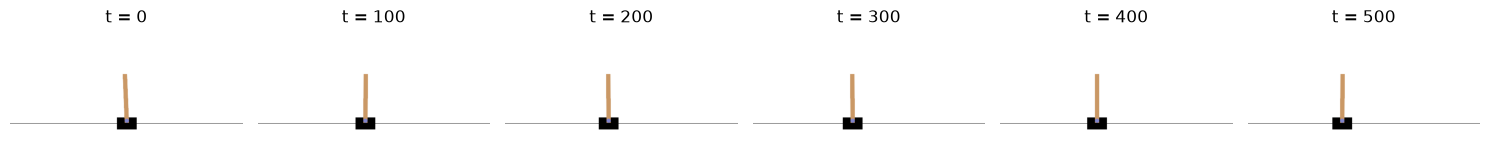

In [5]:
picks = np.linspace(0, len(shots) - 1, 6).round().astype(int)
fig, axes = plt.subplots(1, 6, figsize=(15, 2.4))
for ax, i in zip(axes, picks):
    t, frame = shots[i]
    ax.imshow(frame[60:350, :])
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "ch08_a2c_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 3-3節のエピソードから、等間隔に選んだ 6 枚（t = 0、100、200、300、400、500）です。t = 0 で真ん中にいた台車は、少しずつ左へ動き、t = 500 には台車1台分ほど左にいます。棒は、どの時点でもほぼまっすぐに立っています。台車の動いた幅は、第7章の DQN のモデル（右へ大きく寄っていった）より小さくなっています。

3-1節の学習では、第1章と同じく `tensorboard_log="logs"` を指定したので、学習の記録が `logs` フォルダに書き出されています。TensorBoard で見る手順は、[第1章](../ch01_first_training/ch01_first_training.ipynb)の6-2節と同じです（フォルダを `chapters\ch08_cartpole_reinforce\logs` にします）。著者が記録を読んで、`logs` フォルダの中の `a2c_cartpole_1` フォルダに、`rollout/ep_rew_mean`（直近のエピソードの報酬の平均）、`train/policy_loss`（方策の損失。5-4節）、`train/value_loss`（価値の見積もりの損失）、`train/entropy_loss`、`eval/mean_reward`（`EvalCallback` の評価の平均）などの項目があることを確かめました。DQN（第7章）にあった `rollout/exploration_rate`（ε）はありません。

## 4. 読む(1)：方策ネットワーク

3節のモデルの中のネットワーク（`model.policy`）を見ます。第7章の Q ネットワークは、行動ごとの Q 値を出しました。A2C のネットワークは、行動ごとの **確率** と、観測の **価値** の見積もりを出します。

In [6]:
print(model.policy)
n_params = sum(p.numel() for p in model.policy.parameters())
print(f"ネットワークの重みの個数: {n_params:,}")
# 3-3節と同じ始まり方（seed=0）で5歩進め、各時点の観測で、行動ごとの確率と、価値の見積もりと、選んだ行動を表示する
play_env = gym.make("CartPole-v1")
observation, info = play_env.reset(seed=0)
for t in range(5):
    obs_tensor = torch.as_tensor(observation).unsqueeze(0)
    with torch.no_grad():
        probs = model.policy.get_distribution(obs_tensor).distribution.probs[0].numpy()
        value = model.policy.predict_values(obs_tensor)[0, 0].item()
    action = int(probs.argmax())
    print(f"t = {t}: 観測 {np.round(observation, 3)} → 左へ押す {probs[0]:.3f}、右へ押す {probs[1]:.3f}"
          f"（価値 {value:6.2f}） → {['左', '右'][action]}")
    observation, reward, terminated, truncated, info = play_env.step(action)

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)
ネットワークの重みの個数: 9,155
t = 0: 観測 [ 0.014 -0.023 -0.046 -0.048] → 左へ押す 0.962、右へ押す 0.038（価値  99.98） → 左
t = 1: 観測 [ 0.013 -0.217 -0.047  0.

**期待する結果**（上の出力の読み方）: A2C のネットワーク（`ActorCriticPolicy`）は、観測の4つの数を受け取り、2つの道に分かれます。`policy_net` は 4 → 64 → 64 で、その先の `action_net`（64 → 2）が2つの行動の数を出します。`value_net`（`mlp_extractor` の中）も 4 → 64 → 64 で、その先の `value_net`（64 → 1）が1つの数（価値）を出します。層の間は、第7章の DQN の `ReLU` ではなく `Tanh` でつながれています（SB3 の既定）。重みの個数（バイアスを含む）は 9,155 個です。

3-3節と同じ始まり方で5歩進めると、t = 0 では、棒の角度（3つ目の値）が -0.046 で少し左に傾いていて、左へ押す確率が 0.962 なので、左へ押しました。t = 1 では、棒の角速度（4つ目の値）が 0.23 になっていて、右へ押す確率が 0.962 になり、右へ押しました。そのあとも、t = 2 は左（0.994）、t = 3 は右（0.787）、t = 4 は左（0.999）と、左と右を交互に押しています。どの時点も、2つの確率を足すと 1 です。価値の見積もりは、どの時点も 99.98 です。第7章の7節で見たとおり、報酬が 1 ステップに 1 で γ が 0.99 の CartPole では、この値は 100 を超えません。

A2C のネットワークには、2つの出口があります。`action_net` は、行動ごとの数を出し、それを確率に直したものが方策です。この「行動を選ぶ部分」を **Actor**（演じる側）と呼びます。`value_net` は、その観測から先に得られる報酬の合計の見積もり（状態の価値）を出します。この「価値を見積もる部分」を **Critic**（批評する側）と呼びます。A2C は、Actor と Critic を組み合わせた **Actor-Critic** の手法の1つです（概要資料の[強化学習](../../overview/rl.md)）。

学習中は、行動をこの確率に従って **でたらめに選びます**（左へ押す確率が 0.7 なら、10 回に 7 回ほど左）。方策そのものが確率なので、DQN の ε-greedy のような、探索のための別の仕組みを用意していません。評価や GIF では、`deterministic=True` で、確率が一番大きい行動を選びました。

## 5. 読む(2)：PyTorch の REINFORCE のサンプル

方策勾配法のもっとも基本的な形である REINFORCE を、PyTorch で短く書いたサンプルを動かして、読みます。A2C の Critic にあたる部分は無く、方策のネットワーク（4 → 128 → 2）だけを使います。設定は著者が決めた値です（学習率 0.001、γ = 0.99、100,000 ステップ）。第7章の6節と同じく、2,500 ステップごとに 10 回遊ばせて評価し、一番よい時点のネットワークを残します。著者の環境では 75 秒ほどかかりました。

In [7]:
# 方策のネットワーク（観測4つ → 2つの行動それぞれの数。確率に直すと方策になる）
def make_policy_net():
    return nn.Sequential(nn.Linear(4, 128), nn.ReLU(), nn.Linear(128, 2))


# ネットワーク net で、確率が一番大きい行動を選ぶ方策（観測 → 行動の番号）を返す
def greedy_policy(net):
    def policy(observation):
        with torch.no_grad():
            return int(net(torch.as_tensor(observation)).argmax())
    return policy


# REINFORCE で total_steps ステップ学習させる。normalize=False で収益の標準化を外す
# 学習後のネットワークと、2,500 ステップごとの評価で一番よかった時点のネットワークと、
# エピソードごとの報酬の合計と、評価の記録（ステップ数, 平均）の一覧を返す
def reinforce(total_steps=100_000, lr=1e-3, gamma=0.99, normalize=True, seed=0):
    torch.manual_seed(seed)
    env = gym.make("CartPole-v1")
    net = make_policy_net()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    best_net, best_score = copy.deepcopy(net), -1.0
    episode_rewards, evals, steps = [], [], 0
    observation, info = env.reset(seed=seed)
    while steps < total_steps:
        # 1. 今の方策の確率に従って行動を選び、1エピソードを最後まで進める
        log_probs, rewards = [], []
        while True:
            dist = torch.distributions.Categorical(logits=net(torch.as_tensor(observation)))
            action = dist.sample()
            log_probs.append(dist.log_prob(action))  # 選んだ行動の確率の対数
            observation, reward, terminated, truncated, info = env.step(int(action))
            rewards.append(reward)
            steps += 1
            if terminated or truncated:
                break
        observation, info = env.reset()
        episode_rewards.append(sum(rewards))
        # 2. 各時点から先の収益 G = 報酬 + γ × 次の時点の G を、エピソードの後ろから計算する
        G, returns = 0.0, []
        for reward in reversed(rewards):
            G = reward + gamma * G
            returns.append(G)
        returns = torch.tensor(returns[::-1])
        # 3. 収益を標準化する（エピソードの中で、平均を引いて標準偏差で割る）
        if normalize:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        # 4. 収益が大きかった行動ほど、その確率が上がるように、ネットワークの重みを少し動かす
        loss = -(torch.stack(log_probs) * returns).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 2,500 ステップごとに 10 回遊ばせて評価し、一番よい時点のネットワークを残す
        while steps >= (len(evals) + 1) * 2500:
            eval_step = (len(evals) + 1) * 2500
            score, _ = evaluate(greedy_policy(net), episodes=10, seed=200 + eval_step)
            evals.append((eval_step, score))
            if score > best_score:
                best_net, best_score = copy.deepcopy(net), score
    return net, best_net, episode_rewards, evals


start = time.perf_counter()
net, best_net, rf_rewards, rf_evals = reinforce()
print(f"学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print("学習中のエピソードの数:", len(rf_rewards))
for name, n in [("最後の時点", net), ("一番よい時点", best_net)]:
    mean, std = evaluate(greedy_policy(n))
    print(f"{name}のネットワーク: 報酬の合計の平均 {mean:.1f}、標準偏差 {std:.1f}")

学習にかかった時間: 72 秒
学習中のエピソードの数: 569


最後の時点のネットワーク: 報酬の合計の平均 496.4、標準偏差 18.1


一番よい時点のネットワーク: 報酬の合計の平均 499.1、標準偏差 8.7


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 72 秒でした。100,000 ステップの間に、エピソードは 569 回ありました。最後の時点（100,000 ステップ）のネットワークは平均 496.4（標準偏差 18.1）、一番よい時点のネットワークは平均 499.1（標準偏差 8.7）です。一番よい時点のネットワークは、この章の完了条件（475 以上）を満たしています。

著者が学習の seed を 0〜4 に変えて測ったところ、一番よい時点のネットワークの平均は 493.1〜499.7、最後の時点のネットワークは 489.7〜500.0 でした。どの seed でも、完了条件の 475 を超えました。

### 5-1. 行動を確率で選ぶ

```python
dist = torch.distributions.Categorical(logits=net(torch.as_tensor(observation)))
action = dist.sample()
log_probs.append(dist.log_prob(action))
```

ネットワークが出す2つの数を、`Categorical`（いくつかの中から1つを、決まった確率で選ぶ分布）に渡すと、確率の大きさに応じて行動を選べます（`dist.sample()`）。ネットワークの2つの数を確率に直す計算（ソフトマックス）は、`Categorical` の中で行われます。あとで重みを動かすために、選んだ行動の確率の対数（`log_prob`）を、エピソードの間ずっと貯めておきます。

### 5-2. 収益を計算する

```python
G, returns = 0.0, []
for reward in reversed(rewards):
    G = reward + gamma * G
    returns.append(G)
```

エピソードが終わってから、各時点から先の報酬の割引きの合計（収益）を、後ろから計算します。第6章のモンテカルロ法と同じく、エピソードを最後まで進めてから、実際に得た報酬で計算します。DQN のように、次の観測の価値の見積もりは使いません。

### 5-3. 損失を作って重みを動かす

```python
loss = -(torch.stack(log_probs) * returns).sum()
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

「選んだ行動の確率の対数 × その時点から先の収益」をエピソードの中で足し、符号を逆にしたものを損失にします。この損失を小さくする向きに重みを動かすと、収益が大きかった行動ほど、その確率が大きく上がります。重みを動かす3行（`zero_grad`・`backward`・`step`）は、第7章の DQN と同じです。違うのは損失の作り方で、DQN は目標の Q 値とのずれ、REINFORCE は確率の対数と収益の積です（概要資料の [PyTorch](../../overview/pytorch.md) の図の②）。

1つのエピソードの経験は、1回の重みの更新に使ったら捨てます。次のエピソードは、更新した後の方策で集め直します。第7章の DQN のように、リプレイバッファに貯めて何度も使うことはしません。REINFORCE は、今の方策で集めた経験で、その方策自身を改める **方策オン** の手法です。

### 5-4. A2C との関係

SB3 2.9.0 の A2C のソース（`stable_baselines3/a2c/a2c.py`）では、方策の損失を次のように計算しています。

```python
policy_loss = -(advantages * log_prob).mean()
```

形は REINFORCE と同じ「確率の対数 × 何かの値」で、収益の代わりに **アドバンテージ**（得た報酬の合計が、Critic の見積もった価値よりどれだけ大きかったか）を掛けます。SB3 の A2C は、このほかに、Critic の見積もりを実際の報酬に近づける損失（`value_loss`）も同時に小さくします。また、エピソードの終わりまで待たず、各環境を 5 ステップ進めるたびに重みを動かします（既定の `n_steps=5`）。5 ステップ先からあとの報酬は、Critic の見積もりで補います。

## 6. 比べる：収益の標準化を外す

5節のサンプルの3番目の手順「収益の標準化」を外した設定（`normalize=False`。収益をそのまま掛ける）を学習させ、5節の設定と比べます。著者の環境では 70 秒ほどかかりました。

raw: 学習にかかった時間 70 秒
設定         一番よい時点の平均   最後の時点の平均


normalized          499.1              496.4


raw                 492.5              491.0


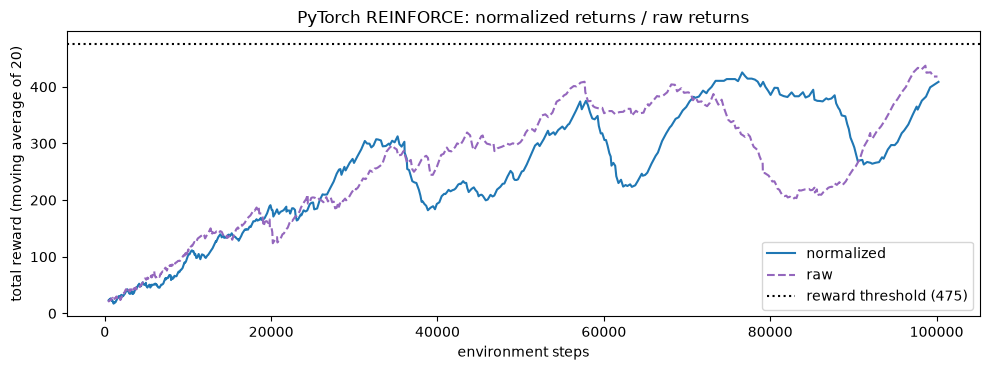

In [8]:
results = {"normalized": (net, best_net, rf_rewards, rf_evals)}
start = time.perf_counter()
results["raw"] = reinforce(normalize=False)
print(f"raw: 学習にかかった時間 {time.perf_counter() - start:.0f} 秒")

print("設定         一番よい時点の平均   最後の時点の平均")
for name, (last, best, _, _) in results.items():
    best_mean, _ = evaluate(greedy_policy(best))
    last_mean, _ = evaluate(greedy_policy(last))
    print(f"{name:10s} {best_mean:14.1f} {last_mean:18.1f}")

fig, ax = plt.subplots(figsize=(10, 3.8))
window = 20
styles = {"normalized": ("tab:blue", "-"), "raw": ("tab:purple", "--")}
for name, (_, _, rewards, _) in results.items():
    rewards = np.array(rewards)
    moving = np.convolve(rewards, np.ones(window) / window, mode="valid")
    color, linestyle = styles[name]
    ax.plot(np.cumsum(rewards)[window - 1:], moving, color=color, linestyle=linestyle, label=name)
ax.axhline(475, color="black", linestyle=":", label="reward threshold (475)")
ax.set_xlabel("environment steps")
ax.set_ylabel(f"total reward (moving average of {window})")
ax.set_title("PyTorch REINFORCE: normalized returns / raw returns")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "ch08_compare.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 標準化を外した設定（`raw`）の学習は 70 秒でした。表の2行は、5節の標準化した設定（`normalized`）と、外した設定の結果です。一番よい時点のネットワークの平均は、`normalized` が 499.1、`raw` が 492.5、最後の時点のネットワークの平均は、`normalized` が 496.4、`raw` が 491.0 です。この seed 0 の1回では、どちらも 475 を超えていて、差は小さくなりました。

図は、学習中の報酬の合計（直前 20 回の平均）です。学習中は確率に従って行動を選んでいて、評価（確率が一番大きい行動を選ぶ）とは選び方が違います。青い実線の `normalized` も紫の破線の `raw` も、30,000 ステップのあたりまでは同じように 300 前後まで上がり、そのあとは上下を繰り返しながら、最後は 400 あたりにいます。どちらも、直前 20 回の平均が 475 に届いた時点はありません。

著者が学習の seed を 0〜4 に変えて測った値は、次のとおりです（学習率 0.001）。

| 設定 | 一番よい時点の平均 | 最後の時点の平均 |
|---|---|---|
| 標準化あり（`normalized`） | 493.1〜499.7 | 489.7〜500.0 |
| 標準化なし（`raw`） | 455.2〜500.0 | 177.0〜500.0 |

標準化なしの設定は、一番よい時点で 475 に届かない seed が1つ（seed 3 の 455.2）、最後の時点で 200 を下回る seed が1つ（seed 4 の 177.0）ありました。標準化ありの設定は、どちらも、すべての seed で 475 を超えました。学習率を 0.01 にした場合の値は、8節に書きました。

標準化すると、1つのエピソードの中の収益は、平均が 0、標準偏差が 1 になります。収益が平均より大きかった時点の行動は確率が上がり、小さかった時点の行動は確率が下がります。標準化しないと、CartPole の収益はどの時点も正の値なので、損失は、選んだ行動の確率を上げる向きの項ばかりの和になり、各項の重みは収益の大きさ（1〜約 100）で変わります。

## 7. 比べる：DQN と

3節の A2C と、5節の REINFORCE の、学習中の評価（10 回の平均）を、横軸を「それまでに進めたステップ数」にして並べます。

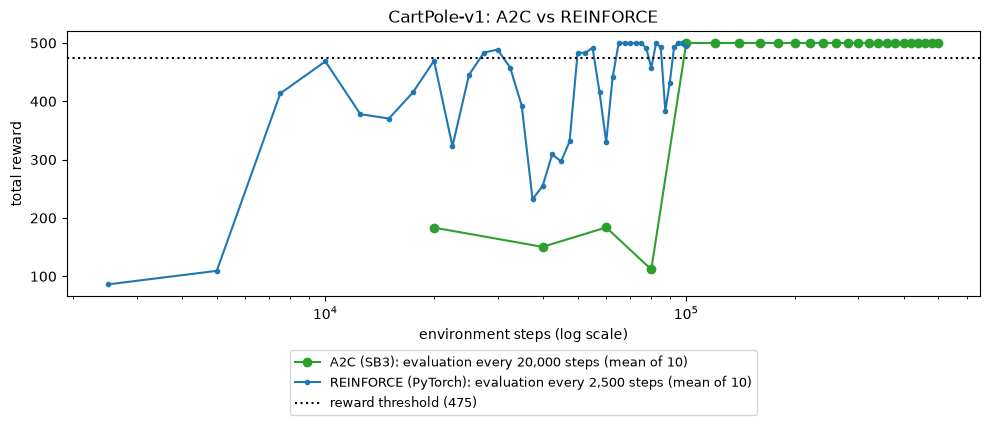

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(eval_callback.evaluations_timesteps, a2c_evals, "o-", color="tab:green",
        label="A2C (SB3): evaluation every 20,000 steps (mean of 10)")
rf_steps, rf_scores = zip(*rf_evals)
ax.plot(rf_steps, rf_scores, ".-", color="tab:blue", label="REINFORCE (PyTorch): evaluation every 2,500 steps (mean of 10)")
ax.axhline(475, color="black", linestyle=":", label="reward threshold (475)")
ax.set_xscale("log")
ax.set_xlabel("environment steps (log scale)")
ax.set_ylabel("total reward")
ax.set_title("CartPole-v1: A2C vs REINFORCE")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "ch08_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 緑の点が3節の A2C の 20,000 ステップごとの評価、青い点が5節の REINFORCE の 2,500 ステップごとの評価（どちらも 10 回の平均）、黒い点線が「解けた」の目安の 475 です。横軸は対数の目盛りで、1目盛りごとにステップ数が 10 倍になります。

青い点は、2,500 ステップと 5,000 ステップでは 100 前後で、7,500〜10,000 ステップで 400 を超えました。そのあとは 230〜490 あたりを上下し、65,000 ステップで初めて 500.0 になりました。一番よい時点のネットワークとして残ったのは、この 65,000 ステップの時点です（それまでの一番よい平均を上回ったときだけ残すため）。そのあとも、400 を下回る評価がありました。緑の点は、20,000〜80,000 ステップでは 200 に届かず、100,000 ステップで 500.0 になってからは、500,000 ステップまで 500.0 のままです。

第7章の DQN と、この章の2つの手法の結果を、著者が学習の seed を 0〜4 に変えて測った値で並べます。

| 手法 | 章 | 学習のステップ数 | 一番よい時点の平均 | 最後の時点の平均 |
|---|---|---|---|---|
| DQN（SB3、RL Zoo の値） | 第7章 | 50,000 | すべて 500.0 | 121.0〜500.0 |
| DQN（PyTorch のサンプル） | 第7章 | 50,000 | 436.3〜500.0 | 89.9〜500.0 |
| A2C（SB3、RL Zoo の値） | 第8章 | 500,000 | （使っていない） | すべて 500.0 |
| REINFORCE（PyTorch のサンプル） | 第8章 | 100,000 | 493.1〜499.7 | 489.7〜500.0 |

学習のステップ数も、ネットワークの大きさなどの設定も、手法ごとに違います。そのため、この表から、どの手法が優れているかは言えません。この表から分かるのは、次のことです。

- この章の2つの手法は、DQN の2倍（REINFORCE）と10倍（A2C）のステップを使いました。DQN は、リプレイバッファに貯めた経験を何度も使います。REINFORCE と A2C は、集めた経験を1回の重みの更新に使ったら捨てます（5-3節・5-4節）
- この設定では、最後の時点の平均は、A2C と REINFORCE のほうが DQN より seed によるばらつきが小さくなりました

## 8. 遊んでみる

**やってみよう**:

- 5節の `reinforce()` の `lr`（学習率）を変えてみてください。著者が学習の seed 0〜4 で `lr=1e-2` を試したところ、一番よい時点は 497.8〜500.0、最後の時点は 48.8〜500.0 でした。さらに標準化を外すと（`lr=1e-2, normalize=False`）、一番よい時点は 158.5〜500.0（seed 1 が 158.5）、最後の時点は 133.5〜500.0 でした
- 5節の `reinforce()` の `gamma` を変えてみてください。著者が seed 0〜4 で `gamma=0.9` を試したところ、一番よい時点は 468.1〜500.0、最後の時点は 291.1〜500.0 でした
- 3-1節の `A2C(...)` の `seed` や、`model.learn` の `total_timesteps` を変えてみてください。著者が seed を 0〜4 に変えて測ったところ、最後の時点のモデルはどれも 500.0 でした。学習中の評価（3-1節の出力）が初めて 500.0 になったのは、20,000〜100,000 ステップでした
- 5節の `make_policy_net()` の中間の層の大きさ（128）を変えてみてください

## 9. まとめ

この章では、CartPole を、方策勾配法で解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| SB3 の A2C を RL Zoo の値で学習させる | `A2C`、`make_vec_env(n_envs=8)` | 3節 |
| 方策ネットワークが出す確率と価値を見る | `model.policy` | 4節 |
| PyTorch の REINFORCE のサンプルを読む | `reinforce()`、`Categorical`、収益 | 5節 |
| 収益の標準化を外して比べる | `normalize=False` | 6節 |
| DQN の結果と並べる | 第7章の値 | 7節 |

方策勾配法は、Q 値を経由せず、行動を選ぶ確率をネットワークで表し、収益が大きかった行動の確率を上げるように学びます。REINFORCE は、1エピソードを最後まで進めてから、実際に得た収益で重みを動かしました。この章の設定では、収益を標準化したほうが、seed によるばらつきが小さくなりました。A2C は、同じ形の損失で、収益の代わりに Critic の見積もりを使ったアドバンテージを掛ける手法です。第1章で使った PPO も、Actor と Critic を組み合わせた方策オンの手法です。

- 次に読むもの: 第9章 MountainCar／Acrobot（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第9章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0・Stable-Baselines3 2.9.0 のソースと動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。PyTorch のサンプルのコードは著者が書いたものです。

- R. J. Williams, "Simple statistical gradient-following algorithms for connectionist reinforcement learning", *Machine Learning*, 8, 229–256, 1992（REINFORCE）
- V. Mnih et al., "Asynchronous methods for deep reinforcement learning", *Proceedings of the 33rd International Conference on Machine Learning (ICML)*, 2016（A2C のもとになった A3C）
- Stable-Baselines3 のソース（v2.9.0。`stable_baselines3/a2c/a2c.py` の既定値と損失、`stable_baselines3/common/callbacks.py` の `EvalCallback`）: https://github.com/DLR-RM/stable-baselines3/tree/v2.9.0/stable_baselines3
- RL Baselines3 Zoo, v2.9.0 の `hyperparams/a2c.yml`（CartPole-v1 のハイパーパラメータ）: https://github.com/DLR-RM/rl-baselines3-zoo/blob/v2.9.0/hyperparams/a2c.yml
- Farama Foundation, Gymnasium Documentation（CartPole の環境の説明）: https://gymnasium.farama.org/environments/classic_control/cart_pole/

3節の GIF とコマ送りの図の絵は、Gymnasium（MIT License）の CartPole の描画処理が出力したものです。グラフは、著者が matplotlib で描いたものです。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。